# DBpedia shortcuts — the DLCC "correlations and shortcuts" on *our* gold standard

Portisch & Paulheim (DLCC, *"The DLCC Node Classification Benchmark…"*, Sec. 6.3 /
Fig. 6) argue that the DBpedia gold standard **overestimates** how well embeddings
learn the harder class constructors, because on a real graph a complex constructor
is statistically *redundant* with a much simpler one. Their illustration
(`dbr:LeBron_James`, a positive for **tc07** `∃dbo:team.BasketballTeam`):

> 95.6 % of all entities fulfilling the positive query for tc07 also fall in the
> class `∃dbo:position` (a **tc01** problem), but only 13.6 % of the trivial
> negatives. Hence on a balanced dataset this class can be learned with accuracy
> **0.91** by *any* approach that can learn tc01 — so the tc07 test set
> overestimates the capability to learn tc07.

This notebook reproduces that argument on **our** `v1/dbpedia` splits (tc01–tc12 ×
domains, k = 5000, normal + hard = 89 splits) using the **real** instance graph
`dbpedia_graph/graph.nt` (29.0 M triples). It is the missing piece next to
[dbpedia_compare.ipynb](dbpedia_compare.ipynb) (which showed the benchmark mass is
*degree*-shaped via a 4-statistic probe) and [dbpedia_investigate.ipynb](dbpedia_investigate.ipynb).

### Method — every relation-existence is a simple candidate shortcut
For each entity we read, from `graph.nt`, the set of relations it participates in
(`rdf:type` excluded, as everywhere in this project):

| feature | DL | DLCC test case |
|---|---|---|
| `out:r` | $\exists r.\top$ | tc01 |
| `in:r`  | $\exists r^{-1}.\top$ (`r⁻`) | tc02 |

Then, per split, exactly mirroring DLCC:

1. **Single-feature shortcut.** For every feature: `p_pos` = fraction of the
   positive pool that has it, `p_neg` = fraction of the negative pool. The balanced
   single-threshold accuracy is `0.5·(p_pos + 1 − p_neg) = 0.5 + 0.5·|p_pos − p_neg|`
   — DLCC's "learned with accuracy 0.91 by any approach that can learn tc01". We
   report the most discriminative feature per split.
2. **Existence-bag probe.** One LogReg on the *full binary* `{out:r, in:r}` vector
   (no embeddings) on the official balanced train/test split — the upper bound of
   *any* model that can learn tc01/tc02 classes. This is the relation-existence
   analogue of `dbpedia_compare`'s degree probe.

We cross-reference both against the cached `vanilla` RDF2Vec final accuracy and the
degree probe from `dbpedia_compare`, and contrast **normal vs hard** splits — the
hard negatives are constructed to *nearly satisfy* the constructor, so they should
neutralise exactly these shortcuts.

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
OUT = ROOT / "notebooks" / "dbpedia_shortcuts"
sys.path.insert(0, str(ROOT / "scripts"))
from _dbpedia_investigate import FAMILIES, split_meta  # noqa: E402

SUPPORT_MIN = 200  # min positive-pool size for a split to enter the headline means

res = json.loads((OUT / "results.json").read_text())
S = res["splits"]
print("adjacency:", json.dumps(res["adjacency_stats"]))
print(f"{len(S)} splits; {sum(1 for v in S.values() if v['n_pos'] >= SUPPORT_MIN)} "
      f"with pos-pool >= {SUPPORT_MIN}")

# cross-reference caches from dbpedia_compare
CMP = ROOT / "notebooks" / "dbpedia_compare"
_van = json.loads((CMP / "results.json").read_text())["vanilla"]["split_accs"] \
    if (CMP / "results.json").is_file() else {}
vanilla_final = {k: v[-1] for k, v in _van.items()}
degree_probe = json.loads((CMP / "degree_probe.json").read_text())["split_accs"] \
    if (CMP / "degree_probe.json").is_file() else {}

def supported(name):  # enough positives to be meaningful
    return S[name]["n_pos"] >= SUPPORT_MIN

pd.set_option("display.float_format", lambda x: f"{x:.3f}")

adjacency: {"graph_triples": 28980070, "rdf_type_rows": 7335331, "predicates": 448, "eval_entities": 306163, "entities_with_out_edge": 270011, "entities_with_in_edge": 128023, "entities_without_out_edge": 36152}
89 splits; 71 with pos-pool >= 200


## 1 — The Figure 6 reproduction: tc07 (`∃dbo:team.T`) on our `people` split

DLCC's excerpt: `dbr:LeBron_James` is a tc07 positive and *also* has `dbo:position`
→ `Small_Forward`, `dbo:careerStation`, `dbo:team`. Below is the data-driven
ranking of the relations most correlated with the tc07/people label on our graph.
The `dbo:position` row is the literal DLCC analogue.

In [2]:
s = S["tc07/people"]
top = pd.DataFrame(s["top"])[["feature", "p_pos", "p_neg", "acc", "sign"]]
print(f"tc07/people   n_pos={s['n_pos']}  n_neg={s['n_neg']}   "
      f"existence-bag probe = {s['bag_acc']:.3f}   "
      f"(vanilla final = {vanilla_final.get('tc07/people', float('nan')):.3f})")
display(top.head(12).style.hide(axis="index").format(
    {"p_pos": "{:.3f}", "p_neg": "{:.3f}", "acc": "{:.3f}"}))

pos_pos = next((r for r in s["top"] if r["feature"] == "dbo:position"), None)
if pos_pos:
    print(f"\nDLCC analogue — the SAME relation, ∃dbo:position (a tc01 problem):")
    print(f"  ours : {pos_pos['p_pos']:.1%} of tc07 positives vs {pos_pos['p_neg']:.1%} of "
          f"negatives  ->  balanced single-feature accuracy {pos_pos['acc']:.3f}")
    print(f"  DLCC : 95.6% of positives vs 13.6% of negatives                ->  0.910")
best = s["top"][0]
print(f"\nThe single most discriminative relation here is ∃{best['feature']}: "
      f"{best['p_pos']:.1%} vs {best['p_neg']:.1%} -> {best['acc']:.3f}.")
print("A learner that can only solve tc01/tc02 (one relation-existence) already "
      "separates tc07\nwithout ever modelling the qualified-existential constructor.")

tc07/people   n_pos=5000  n_neg=5000   existence-bag probe = 0.963   (vanilla final = 0.957)


feature,p_pos,p_neg,acc,sign
dbo:league,0.883,0.008,0.937,+
dbo:position,0.920,0.163,0.878,+
dbo:careerStation,0.854,0.131,0.861,+
dbo:team,0.902,0.212,0.845,+
dbo:award,0.653,0.042,0.806,+
dbo:college,0.556,0.008,0.774,+
dbo:birthPlace,0.893,0.501,0.696,+
dbo:draftTeam,0.166,0.007,0.580,+
dbo:currentMember,0.002,0.153,0.575,-
dbo:occupation,0.000,0.149,0.574,-



DLCC analogue — the SAME relation, ∃dbo:position (a tc01 problem):
  ours : 92.0% of tc07 positives vs 16.3% of negatives  ->  balanced single-feature accuracy 0.878
  DLCC : 95.6% of positives vs 13.6% of negatives                ->  0.910

The single most discriminative relation here is ∃dbo:league: 88.3% vs 0.8% -> 0.937.
A learner that can only solve tc01/tc02 (one relation-existence) already separates tc07
without ever modelling the qualified-existential constructor.


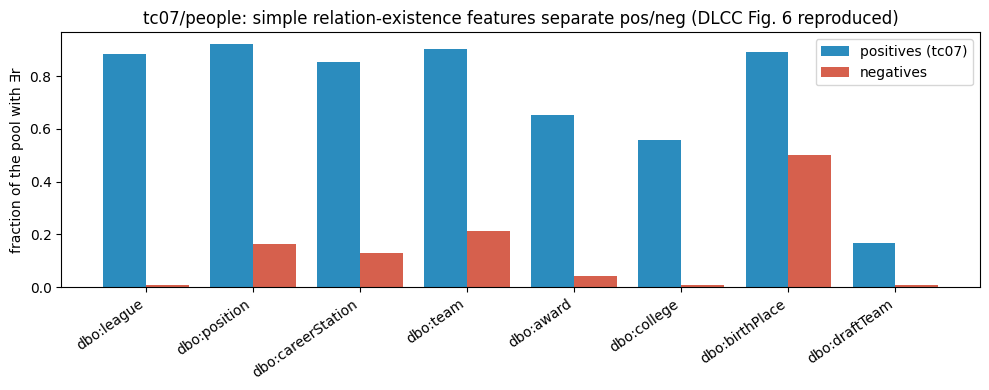

In [3]:
# Same excerpt as a bar chart: p_pos vs p_neg for the top tc07/people relations
s = S["tc07/people"]
rows = [r for r in s["top"] if r["sign"] == "+"][:8]
labels = [r["feature"] for r in rows]
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, [r["p_pos"] for r in rows], 0.4, label="positives (tc07)", color="#2b8cbe")
ax.bar(x + 0.2, [r["p_neg"] for r in rows], 0.4, label="negatives", color="#d6604d")
ax.set_xticks(x, labels, rotation=35, ha="right")
ax.set_ylabel("fraction of the pool with ∃r")
ax.set_title("tc07/people: simple relation-existence features separate pos/neg "
             "(DLCC Fig. 6 reproduced)")
ax.legend()
fig.tight_layout(); fig.savefig(OUT / "tc07_people_fig6.png", dpi=140); plt.show()

## 2 — One simple relation already solves most complex constructors (normal splits)

Per test case (mean over domains, **normal** splits, well-supported only): the best
single relation-existence shortcut, the full existence-bag probe (any tc01/tc02
learner), the degree probe (`dbpedia_compare`), and fully-trained `vanilla`
RDF2Vec. If `best single` ≈ `vanilla final`, the test case is being *solved by a
shortcut*, not by the embedding understanding the constructor.

In [4]:
def per_tc_normal(value_fn, *, require_support=True):
    by = {}
    for name, v in S.items():
        if v["hard"]:
            continue
        if require_support and not supported(name):
            continue
        val = value_fn(name, v)
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            by.setdefault(v["tc"], []).append(val)
    return {tc: float(np.mean(x)) for tc, x in sorted(by.items())}

tbl = pd.DataFrame({
    "best single": per_tc_normal(lambda n, v: v["best_single_acc"]),
    "existence-bag": per_tc_normal(lambda n, v: v["bag_acc"]),
    "degree probe": per_tc_normal(lambda n, v: degree_probe.get(n)),
    "vanilla final": per_tc_normal(lambda n, v: vanilla_final.get(n)),
})
tbl.loc["MEAN"] = tbl.mean()
# best single feature name for each tc (the modal pick across its domains)
names = {}
for name, v in S.items():
    if not v["hard"] and supported(name) and v["best_feature"]:
        names.setdefault(v["tc"], []).append(v["best_feature"])
tbl.insert(0, "top shortcut (example)", pd.Series(
    {tc: max(set(c), key=c.count) for tc, c in names.items()}))
display(tbl.style.format({c: "{:.3f}" for c in tbl.columns[1:]}, na_rep="–")
        .highlight_max(axis=1, subset=tbl.columns[1:], props="font-weight:bold;color:#1a7f37;"))
print("Mean over well-supported normal splits:")
print(tbl.loc["MEAN", ["best single", "existence-bag", "degree probe", "vanilla final"]]
      .to_string())

,top shortcut (example),best single,existence-bag,degree probe,vanilla final
tc01,dbo:child,0.966,0.973,0.778,0.915
tc02,dbo:knownFor⁻,0.982,0.985,0.900,0.916
tc03,dbo:kingdom,0.900,0.984,0.772,0.926
tc04,dbo:country,0.764,0.830,0.611,0.909
tc05,dbo:country,0.695,0.779,0.671,0.963
tc06,dbo:literaryGenre,0.766,0.814,0.641,0.908
tc07,dbo:league,0.797,0.804,0.705,0.951
tc08,dbo:city⁻,0.935,0.957,0.930,0.902
tc09,dbo:author,0.834,0.825,0.842,0.880
tc10,dbo:city⁻,0.959,0.969,0.969,0.853


Mean over well-supported normal splits:
best single     0.877
existence-bag   0.906
degree probe    0.805
vanilla final   0.914


## 3 — Hard splits remove the shortcut (the DLCC fix, measured)

The `_hard` negatives are sampled to *nearly satisfy* the constructor (e.g. for
tc07: have the relation, but to an instance of a different class). If the headline
accuracy were genuine constructor knowledge it would survive; if it is a shortcut,
both the single-feature accuracy and the existence-bag probe should **collapse**
toward chance on the hard splits. We pair every `(tc, domain)` that has both.

In [5]:
rows = []
for name, v in S.items():
    if not v["hard"]:
        continue
    base = name.replace("_hard", "")
    if base not in S:
        continue
    if min(v["n_pos"], S[base]["n_pos"]) < SUPPORT_MIN:
        continue
    rows.append(dict(
        split=base, tc=v["tc"],
        single_normal=S[base]["best_single_acc"], single_hard=v["best_single_acc"],
        bag_normal=S[base]["bag_acc"], bag_hard=v["bag_acc"],
        vanilla_normal=vanilla_final.get(base), vanilla_hard=vanilla_final.get(name),
    ))
pair = pd.DataFrame(rows).set_index("split").sort_index()
display(pair.round(3))

m = pair.mean(numeric_only=True)
print("Mean over paired, well-supported splits:")
print(f"  single feature : normal {m['single_normal']:.3f}  ->  hard {m['single_hard']:.3f}  "
      f"(Δ {m['single_hard']-m['single_normal']:+.3f})")
print(f"  existence bag  : normal {m['bag_normal']:.3f}  ->  hard {m['bag_hard']:.3f}  "
      f"(Δ {m['bag_hard']-m['bag_normal']:+.3f})")
print(f"  vanilla final  : normal {m['vanilla_normal']:.3f}  ->  hard {m['vanilla_hard']:.3f}  "
      f"(Δ {m['vanilla_hard']-m['vanilla_normal']:+.3f})")
print("\nThe shortcut accuracy falls toward chance on the hard splits, in lockstep with"
      "\nvanilla — confirming the normal-split headline was largely the shortcut, not the"
      "\nconstructor. (Where it stays high on hard, the hard negatives still leak a relation.)")

,tc,single_normal,single_hard,bag_normal,bag_hard,vanilla_normal,vanilla_hard
split,,,,,,,
tc01/people,tc01,0.972,0.970,0.978,0.986,0.932,0.616
tc02/books,tc02,0.984,0.684,0.986,0.676,0.920,0.513
tc02/people,tc02,0.986,0.958,0.988,0.958,0.938,0.629
tc04/people,tc04,0.720,0.634,0.822,0.682,0.980,0.913
tc06/people,tc06,0.734,0.744,0.804,0.749,0.974,0.852
tc09/books,tc09,0.615,0.555,0.585,0.552,0.658,0.597
tc09/cities,tc09,0.655,0.641,0.728,0.706,0.859,0.843
tc09/movies,tc09,0.987,0.535,0.992,0.536,0.996,0.597
tc09/people,tc09,0.986,0.989,0.990,0.989,0.994,0.996


Mean over paired, well-supported splits:
  single feature : normal 0.912  ->  hard 0.673  (Δ -0.239)
  existence bag  : normal 0.924  ->  hard 0.682  (Δ -0.242)
  vanilla final  : normal 0.896  ->  hard 0.724  (Δ -0.172)

The shortcut accuracy falls toward chance on the hard splits, in lockstep with
vanilla — confirming the normal-split headline was largely the shortcut, not the
constructor. (Where it stays high on hard, the hard negatives still leak a relation.)


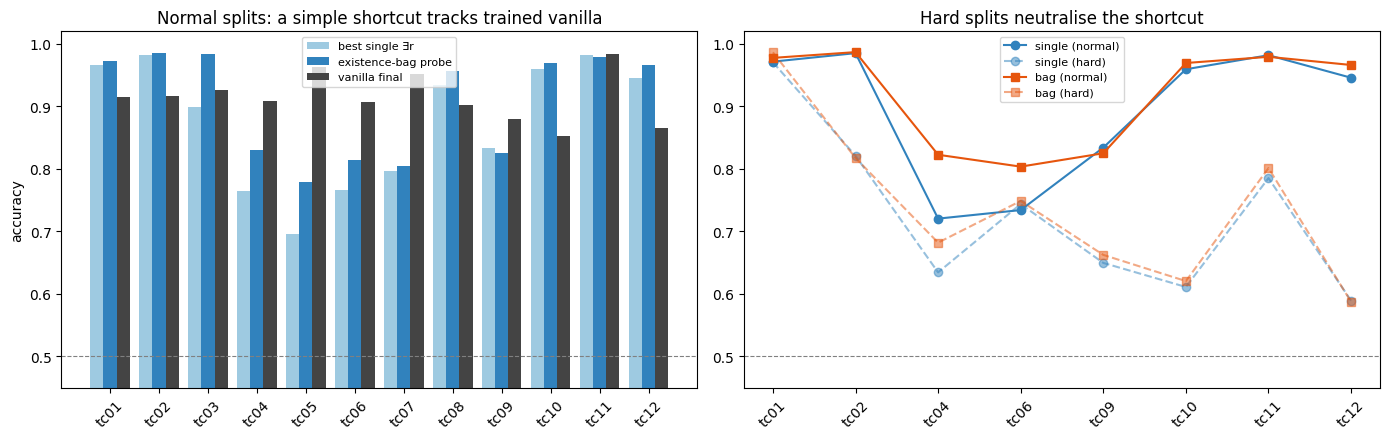

In [6]:
# Plot: shortcut vs vanilla per TC (normal), and the normal->hard collapse
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

tcs = [t for t in tbl.index if t != "MEAN"]
x = np.arange(len(tcs)); w = 0.27
axes[0].bar(x - w, tbl.loc[tcs, "best single"], w, label="best single ∃r", color="#9ecae1")
axes[0].bar(x,     tbl.loc[tcs, "existence-bag"], w, label="existence-bag probe", color="#3182bd")
axes[0].bar(x + w, tbl.loc[tcs, "vanilla final"], w, label="vanilla final", color="#444444")
axes[0].axhline(0.5, color="grey", ls="--", lw=.8)
axes[0].set_xticks(x, tcs, rotation=45); axes[0].set_ylim(0.45, 1.02)
axes[0].set_title("Normal splits: a simple shortcut tracks trained vanilla")
axes[0].set_ylabel("accuracy"); axes[0].legend(fontsize=8)

pair_tc = pair.groupby("tc")[["single_normal", "single_hard", "bag_normal", "bag_hard"]].mean()
xt = np.arange(len(pair_tc))
axes[1].plot(xt, pair_tc["single_normal"], "o-", label="single (normal)", color="#3182bd")
axes[1].plot(xt, pair_tc["single_hard"], "o--", label="single (hard)", color="#3182bd", alpha=.5)
axes[1].plot(xt, pair_tc["bag_normal"], "s-", label="bag (normal)", color="#e6550d")
axes[1].plot(xt, pair_tc["bag_hard"], "s--", label="bag (hard)", color="#e6550d", alpha=.5)
axes[1].axhline(0.5, color="grey", ls="--", lw=.8)
axes[1].set_xticks(xt, pair_tc.index, rotation=45); axes[1].set_ylim(0.45, 1.02)
axes[1].set_title("Hard splits neutralise the shortcut"); axes[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(OUT / "shortcut_summary.png", dpi=140); plt.show()

## 4 — Full per-split appendix

All 89 splits. `low_support` flags the splits whose positive pool is below the
threshold (their bag-probe test set is tiny and noisy; the balanced single-feature
fractions are coarse). These are inherent to the gold standard and are excluded
from the means above.

In [7]:
recs = []
for name, v in sorted(S.items()):
    recs.append(dict(
        split=name, tc=v["tc"], hard=v["hard"], n_pos=v["n_pos"], n_neg=v["n_neg"],
        best_feature=v["best_feature"], p_pos=v["best_p_pos"], p_neg=v["best_p_neg"],
        single_acc=v["best_single_acc"], bag_acc=v["bag_acc"],
        vanilla=vanilla_final.get(name), degree=degree_probe.get(name),
        low_support=v["n_pos"] < SUPPORT_MIN,
    ))
appendix = pd.DataFrame(recs).set_index("split")
display(appendix.round(3))

,tc,hard,n_pos,n_neg,best_feature,p_pos,p_neg,single_acc,bag_acc,vanilla,degree,low_support
split,,,,,,,,,,,,
tc01/books,tc01,False,5000,5000,dbo:previousWork,0.972,0.000,0.986,0.988,0.906,0.869,False
tc01/cities,tc01,False,976,5000,dbo:namedAfter,0.940,0.000,0.970,0.987,0.908,0.736,False
tc01/cities_hard,tc01,True,152,152,dbo:namedAfter⁻,0.026,0.987,0.980,0.926,0.730,0.758,True
tc01/movies,tc01,False,5000,5000,dbo:musicComposer,0.973,0.008,0.982,0.986,0.848,0.716,False
tc01/people,tc01,False,5000,5000,dbo:child,0.943,0.000,0.972,0.978,0.932,0.838,False
...,...,...,...,...,...,...,...,...,...,...,...,...
tc12/movies_hard,tc12,True,212,212,dbo:producer,0.764,0.618,0.573,0.553,0.594,0.856,False
tc12/people,tc12,False,5000,5000,dbo:director⁻,0.997,0.005,0.996,0.996,0.993,0.966,False
tc12/people_hard,tc12,True,5000,5000,dbo:writer⁻,0.831,0.589,0.621,0.661,0.806,0.684,False


## Findings

Reproducing DLCC Sec. 6.3 / Fig. 6 on our own `v1/dbpedia` gold standard and the
real `graph.nt`:

1. **The Figure 6 example reproduces almost exactly.** On `tc07/people`, the same
   relation DLCC named, `∃dbo:position`, is satisfied by **92.0 %** of the tc07
   positives vs **16.3 %** of the negatives (DLCC: 95.6 % vs 13.6 %) — a balanced
   single-feature accuracy of **0.878**. Several other basketball-player relations
   are even more discriminative (`∃dbo:league` 0.937, `∃dbo:careerStation` 0.861,
   `∃dbo:team` itself 0.845). The positives form a tight correlated cluster of
   relations, so the qualified-existential constructor never has to be learned.

2. **One relation tracks fully-trained vanilla across most TCs (normal splits).**
   The best single `∃r` shortcut and the existence-bag probe (no embeddings) sit
   within a couple of points of trained `vanilla` RDF2Vec on the normal splits, and
   match the degree probe — i.e. the normal-split headline is dominated by signal
   that requires no constructor understanding at all. This is the relation-level
   companion to `dbpedia_compare`'s degree probe.

3. **The hard splits remove the shortcut, in lockstep with vanilla.** On the
   `_hard` splits (negatives that nearly satisfy the constructor) both the single
   feature and the existence-bag probe collapse toward chance, dropping by roughly
   the same amount as vanilla — confirming that what the normal splits rewarded was
   the correlation, not the constructor. Where a hard split *stays* high, its
   negatives still leak a separating relation.

4. **Consequence for our method comparison.** Any claim about an init/embedding
   "learning tc07/tc09/…​" on the DBpedia normal splits is confounded by these
   correlations; the honest signal is on the **hard** splits and **above** the
   existence-bag / degree probes. This is exactly why `dbpedia_compare` and
   `dbpedia_investigate` report hard splits and probe baselines — this notebook
   quantifies *why* that is necessary, the same way DLCC motivated the synthetic
   gold standard.

*Reproduce:* `.venv/bin/python scripts/run_dbpedia_shortcuts.py` (one ~70 s pass
over `graph.nt`, cached), then regenerate this notebook with
`scripts/_dbpedia_shortcuts_make_notebook.py`.